## AI 헬스케어 첫 번째 미니 프로젝트
흡연 여부 데이터 분석을 통한 건강 인사이트 도출에 오신 여러분 환영합니다!
우리는 흡연 관련 건강 데이터를 분석하여 시각화하고, 다양한 가설을 검증해보는 과정을 함께 할 것입니다.
A부터 Z까지 친절하게 안내해 드릴 예정이니, 천천히 따라해 보세요!

### 🚬 흡연 여부 데이터 분석하기
최근 여러 기관에서는 흡연이 개인의 건강에 미치는 영향을 정확히 파악하고,
이를 기반으로 예방 중심의 건강관리 정책을 수립하려는 노력을 강화하고 있습니다.

하지만 “흡연 여부”를 직접 조사하는 것은 현실적으로 쉽지 않습니다.
이에 따라, 건강검진 데이터를 통해 흡연 여부를 데이터 기반으로 추정하고,
흡연자와 비흡연자 간의 생체·건강 지표 차이를 검증하려는 프로젝트가 시작되었습니다.

여러분은 이 프로젝트의 데이터 분석가이자 AI 엔지니어로 참여하게 되었습니다.
주어진 데이터에는 개인의 건강검진 결과(혈압, 혈당, 콜레스테롤, BMI 등)와 흡연 여부(label = 0 또는 1)가 포함되어 있습니다.

이제 여러분의 역할은 흡연 여부 데이터의 특성을 분석하고 시각화하며, 통계적 검정을 통해 변수 간 관계를 규명하는 것입니다.
시작해봅시다 !

#### 🎯 프로젝트 목표

- 흡연자와 비흡연자 간의 건강 지표 차이 분석
- 주요 변수들의 분포, 상관관계, 통계적 유의성 검증
- 시각화를 통한 데이터 인사이트 도출
- 추후 흡연 여부 예측 모델 개발을 위한 기초 분석 기반 마련



---



## 0. 라이브러리 불러오기
데이터 분석에 필요한 라이브러리를 먼저 불러옵시다! (ex. pandas, matplotlib, seaborn 등)

##### **[TODO] 라이브러리 로딩**
-  `pandas` 라이브러리를 `pd` 라는 별칭으로 불러오세요.
-  `matplotlib` 라이브러리를 `plt` 라는 별칭으로 불러오세요.
-  `seaborn` 라이브러리를 `sns` 라는 별칭으로 불러오세요.

In [58]:
# 필요한 라이브러리들 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
import matplotlib.font_manager as fm
print([f.name for f in fm.fontManager.ttflist if "Nanum" in f.name])

['NanumGothic', 'NanumSquare', 'NanumSquareRound', 'NanumGothicCoding', 'NanumGothic', 'NanumBarunGothic', 'NanumGothicCoding', 'NanumMyeongjo', 'NanumMyeongjo', 'NanumBarunGothic', 'NanumSquare', 'NanumSquareRound']


In [60]:
#폰트설정
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

print("폰트 설정 완료")

폰트 설정 완료


---
## 1. 데이터 불러오기
모든 데이터 분석의 시작은 '데이터 불러오기' 부터 입니다!

**(예시)**
- csv : pd.read_csv("파일이름. csv")
- txt : pd.read_csv("파일이름. csv", sep="구분자")
- xlsx : pd.read_excel('파일이름.xlsx')
- pickle : pd.read_pickle("파일이름.pkl")

[참고] pickle은 파이썬의 모든 객체를 파일로 저장할 수 있는 방법으로 DataFrame,List,Dict 등 모든 객체 저장 가능
*(특히 sklearn라이브러리를 통해 모델을 학습시키고, 저장할 때 많이 사용됩니다)*

##### **[TODO] 데이터 로딩**
- Pandas의 `read_csv()` 함수를 활용하여 `smoking_health_data.csv` 파일을 `health_data` 변수에 저장하세요.
- `health_data` 데이터프레임의 크기(shape)를 확인하세요.

In [18]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
data = pd.read_csv('smoking_health_data.csv')
health_data = pd.DataFrame(data)
health_data.shape

(7000, 18)

---
## 2. 기본 정보 확인 및 데이터 정제
데이터 정제란 ? 결측치, 이상치 등을 제거하여 데이터 분석 결과가 왜곡 되는 문제를 방지하기 위한 정제 과정입니다.

##### **[TODO] 기본 정보 확인하기**
- `health_data` 데이터의 정보를 확인해보세요.
    -   **`info()`**: 각 컬럼의 데이터 타입, Non-null 값 개수 등을 확인합니다.
    -   **`describe()`**: 숫자형 컬럼의 통계 요약 (평균, 표준편차, 최솟값, 최댓값 등)을 확인합니다.
    -   **`head()`**: 데이터의 상위 5행을 확인하여 샘플 데이터를 살펴봅니다.
    -   **`tail()`**: 데이터의 하위 5행을 확인합니다.

In [50]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
health_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   ID        7000 non-null   str     
 1   나이        7000 non-null   int64   
 2   키(cm)     7000 non-null   int64   
 3   몸무게(kg)   7000 non-null   int64   
 4   BMI       7000 non-null   float64 
 5   시력        7000 non-null   float64 
 6   충치        7000 non-null   int64   
 7   공복 혈당     7000 non-null   float64 
 8   혈압        7000 non-null   float64 
 9   중성 지방     7000 non-null   float64 
 10  혈청 크레아티닌  7000 non-null   float64 
 11  콜레스테롤     7000 non-null   int64   
 12  고밀도지단백    7000 non-null   int64   
 13  저밀도지단백    7000 non-null   int64   
 14  헤모글로빈     7000 non-null   float64 
 15  요 단백      7000 non-null   int64   
 16  간 효소율     7000 non-null   float64 
 17  label     7000 non-null   int64   
 18  BMI 구간    7000 non-null   category
 19  나이대       7000 non-null   category
dtypes: category(2), flo

In [20]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
health_data.describe()

,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label
count,7000.000000,7000.000000,7000.000000,7000.000000,6860.000000,7000.000000,6860.000000,6860.000000,6860.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,43.973571,164.781429,65.932857,24.144423,1.011414,0.227429,99.307289,45.555102,127.028134,0.884900,197.276571,57.355429,115.346857,14.631914,1.083857,1.144696,0.367286
std,12.063793,9.170213,12.978702,3.501945,0.430137,0.419202,21.190058,8.831564,73.219161,0.241523,36.306494,14.506945,41.788153,1.540907,0.392051,0.432735,0.482100
min,20.000000,135.000000,30.000000,14.270000,0.100000,0.000000,57.000000,14.000000,21.000000,0.100000,86.000000,18.000000,1.000000,4.900000,1.000000,0.140000,0.000000
25%,35.000000,160.000000,55.000000,21.600000,0.800000,0.000000,89.000000,40.000000,74.000000,0.800000,173.000000,47.000000,92.000000,13.600000,1.000000,0.840000,0.000000
50%,40.000000,165.000000,65.000000,23.880000,1.000000,0.000000,96.000000,45.000000,107.000000,0.900000,195.000000,55.000000,113.000000,14.800000,1.000000,1.100000,0.000000
75%,50.000000,170.000000,75.000000,26.120000,1.200000,0.000000,104.000000,50.000000,161.000000,1.000000,219.000000,66.000000,136.000000,15.700000,1.000000,1.380000,1.000000
max,85.000000,190.000000,130.000000,42.450000,9.900000,1.000000,386.000000,91.000000,399.000000,10.000000,395.000000,157.000000,1340.000000,20.900000,5.000000,5.670000,1.000000


In [21]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
health_data.head(5)

,ID,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label
0,TRAIN_0000,35,170,70,24.22,1.10,1,98.0,40.0,80.0,1.3,211,75,120,15.9,1,1.53,1
1,TRAIN_0001,40,150,55,24.44,1.00,0,173.0,39.0,104.0,0.6,251,46,184,11.8,1,1.45,0
2,TRAIN_0002,60,170,50,17.30,0.75,0,96.0,40.0,61.0,0.8,144,43,89,15.3,1,1.04,0
3,TRAIN_0003,40,150,45,20.00,0.50,0,92.0,40.0,46.0,0.7,178,66,110,13.4,1,1.18,0
4,TRAIN_0004,55,155,65,27.06,NaN,0,87.0,42.0,95.0,0.9,232,62,151,13.8,1,1.32,0


In [22]:
health_data.tail(5)# 아래에 실습코드를 작성하고 결과를 확인합니다.

,ID,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label
6995,TRAIN_6995,25,170,65,22.49,1.50,0,87.0,45.0,141.0,1.2,184,44,112,14.9,1,1.50,0
6996,TRAIN_6996,60,165,65,23.88,0.90,0,87.0,45.0,82.0,0.9,184,64,103,14.3,1,1.47,1
6997,TRAIN_6997,40,180,100,30.86,1.20,0,97.0,44.0,87.0,0.9,178,54,107,15.6,1,1.00,0
6998,TRAIN_6998,60,150,55,24.44,0.60,0,89.0,57.0,161.0,0.6,157,49,76,14.4,1,1.00,0
6999,TRAIN_6999,50,165,65,23.88,0.65,0,104.0,47.0,124.0,0.8,251,56,170,13.6,1,0.81,0


##### **[TODO] BMI를 기준으로 체중 상태 구분 컬럼 추가**
- `health_data` 데이터프레임에 'BMI 구간'을 기준으로 체중 상태를 나타내는 새로운 컬럼을 추가하세요.

  - 저체중 (18.5 미만)
  - 정상 (18.5 이상 ~ 22.9 이하)
  - 비만전단계 (23 이상 ~ 24.9 이하)
  - 1단계 비만 (25 이상 ~ 29.9 이하)
  - 2단계 비만 (30 이상 ~ 34.9 이하)
  - 3단계 비만 (35 이상)

In [24]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.

bins = [0, 18.5, 23, 25, 30, 35, float("inf")]
labels = ["저체중", "정상", "비만전단계", "1단계 비만", "2단계 비만", "3단계 비만"]
health_data["BMI 구간"] = pd.cut(health_data["BMI"], bins, labels=labels,right = False)
health_data.head(5)

,ID,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label,BMI 구간
0,TRAIN_0000,35,170,70,24.22,1.10,1,98.0,40.0,80.0,1.3,211,75,120,15.9,1,1.53,1,비만전단계
1,TRAIN_0001,40,150,55,24.44,1.00,0,173.0,39.0,104.0,0.6,251,46,184,11.8,1,1.45,0,비만전단계
2,TRAIN_0002,60,170,50,17.30,0.75,0,96.0,40.0,61.0,0.8,144,43,89,15.3,1,1.04,0,저체중
3,TRAIN_0003,40,150,45,20.00,0.50,0,92.0,40.0,46.0,0.7,178,66,110,13.4,1,1.18,0,정상
4,TRAIN_0004,55,155,65,27.06,NaN,0,87.0,42.0,95.0,0.9,232,62,151,13.8,1,1.32,0,1단계 비만


##### **[TODO] 나이를 기준으로 나이대 구분 컬럼 추가**
- `health_data` 데이터프레임에 '나이'를 기준으로 나이대를 구분하는 새로운 컬럼을 추가하세요.

  - 20대
  - 30대
  - 40대
  - 50대
  - 60대
  - 70대
  - 70대 초과

In [25]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
bins = [20,30,40,50,60,70,80,float("inf")]
labels = ['20대','30대','40대','50대','60대','70대','70대 초과']
health_data["나이대"] = pd.cut(health_data["나이"], bins, labels=labels,right = False)
health_data.head(5)

,ID,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label,BMI 구간,나이대
0,TRAIN_0000,35,170,70,24.22,1.10,1,98.0,40.0,80.0,1.3,211,75,120,15.9,1,1.53,1,비만전단계,30대
1,TRAIN_0001,40,150,55,24.44,1.00,0,173.0,39.0,104.0,0.6,251,46,184,11.8,1,1.45,0,비만전단계,40대
2,TRAIN_0002,60,170,50,17.30,0.75,0,96.0,40.0,61.0,0.8,144,43,89,15.3,1,1.04,0,저체중,60대
3,TRAIN_0003,40,150,45,20.00,0.50,0,92.0,40.0,46.0,0.7,178,66,110,13.4,1,1.18,0,정상,40대
4,TRAIN_0004,55,155,65,27.06,NaN,0,87.0,42.0,95.0,0.9,232,62,151,13.8,1,1.32,0,1단계 비만,50대


In [155]:
health_data['나이대'].value_counts().sum()

np.int64(7000)

##### **[TODO] 결측치 확인하기**
- `health_data` 데이터프레임의 모든 컬럼에 대한 결측치(NaN)를 확인하세요.

In [152]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
missing_count = health_data.isnull().sum()  # Series반환 (True=1, False=0으로 계산)
print("컬럼별 결측치 개수:")
print(missing_count)

컬럼별 결측치 개수:
ID          0
나이          0
키(cm)       0
몸무게(kg)     0
BMI         0
시력          0
충치          0
공복 혈당       0
혈압          0
중성 지방       0
혈청 크레아티닌    0
콜레스테롤       0
고밀도지단백      0
저밀도지단백      0
헤모글로빈       0
요 단백        0
간 효소율       0
label       0
BMI 구간      0
나이대         0
dtype: int64


결측치는 분석 결과에 왜곡을 줄 수 있으므로 반드시 확인하고 적절히 처리해야 합니다.  
일반적으로 평균, 중앙값, 최빈값으로 채우지만, 해당 변수의 의미를 고려하여 방법을 선택해야 합니다.

##### **[TODO] 결측치 처리**
- `health_data`의 결측치를 적절한 방법으로 처리하세요.

**(예시)**
- 혈압은 중앙값으로 채우기
- 시력은 최빈값으로 채우기
- 나이대별 중성지방은 그룹 평균으로 채우기
- 공복 혈당은 평균으로 채우기

이거 health_data.groupby(by="나이대").mean()하면 그룹단위의 평균이 나오는데
데이터셋 전체의 index와 매치가 안돼서 그래요


In [44]:
health_age_group = health_data.groupby(by="나이대")
health_age_group['중성 지방'].transform('mean').head(5)


0    140.770221
1    123.939548
2    127.630559
3    123.939548
4    131.211673
Name: 중성 지방, dtype: float64

In [49]:
health_data["시력"].mode()

0    1.2
Name: 시력, dtype: float64

In [47]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
health_data["혈압"] = health_data["혈압"].fillna(health_data["혈압"].median())
health_data["시력"] = health_data["시력"].fillna(health_data["시력"].mode()[0])
health_data["공복 혈당"] = health_data["공복 혈당"].fillna(health_data["공복 혈당"].mean())
health_data['중성 지방'] = health_data['중성 지방'].fillna(health_age_group['중성 지방'].transform('mean'))

In [48]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
missing_count = health_data.isnull().sum()  # Series반환 (True=1, False=0으로 계산)
print("컬럼별 결측치 개수:")
print(missing_count)

컬럼별 결측치 개수:
ID          0
나이          0
키(cm)       0
몸무게(kg)     0
BMI         0
시력          0
충치          0
공복 혈당       0
혈압          0
중성 지방       0
혈청 크레아티닌    0
콜레스테롤       0
고밀도지단백      0
저밀도지단백      0
헤모글로빈       0
요 단백        0
간 효소율       0
label       0
BMI 구간      0
나이대         0
dtype: int64


In [77]:
# 이상치 대체

health_data.loc[health_data['저밀도지단백']>500, '저밀도지단백'] = None
health_data['저밀도지단백'] = (health_data
                         .groupby(by = '나이대')['저밀도지단백']
                         .transform(lambda x : x.fillna(x.median()))
                         )


In [96]:
health_data.loc[health_data['시력']>3, '시력'] = None
health_data.loc[health_data['혈청 크레아티닌']>8, '혈청 크레아티닌'] = None

In [97]:
health_data['시력'] = health_data['시력'].fillna(health_data['시력'].mode()[0])
health_data['혈청 크레아티닌'] = health_data['혈청 크레아티닌'].fillna(health_data['혈청 크레아티닌'].median())


---
## 3. 데이터 분석하기

데이터의 형태를 파악하고 다양한 분석 기법을 활용하여, 모델링에 적합한 변수를 선별하는 방법을 알아봅니다.
- 데이터들의 패턴 탐색
- 변수들 간의 관계 파악

##### **[TODO] 데이터 분포 알아보기**
- `health_data`의 주요 변수들에 대해 다양한 시각화(boxplot, histogram, scatterplot 등)를 통해 데이터 분포를 확인하고, 인사이트를 도출하세요.
- 데이터의 형태와 분포를 시각화하면 이상치, 극단값, 데이터 패턴을 쉽게 파악할 수 있습니다!

In [98]:
health_data.describe()

,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,43.973571,164.781429,65.932857,24.144423,0.996379,0.227429,99.307289,45.544000,127.021938,0.883600,197.276571,57.355429,114.707143,14.631914,1.083857,1.144696,0.367286
std,12.063793,9.170213,12.978702,3.501945,0.298672,0.419202,20.977056,8.743135,72.492839,0.215547,36.306494,14.506945,33.686005,1.540907,0.392051,0.432735,0.482100
min,20.000000,135.000000,30.000000,14.270000,0.100000,0.000000,57.000000,14.000000,21.000000,0.100000,86.000000,18.000000,1.000000,4.900000,1.000000,0.140000,0.000000
25%,35.000000,160.000000,55.000000,21.600000,0.800000,0.000000,89.000000,40.000000,74.000000,0.800000,173.000000,47.000000,92.000000,13.600000,1.000000,0.840000,0.000000
50%,40.000000,165.000000,65.000000,23.880000,1.000000,0.000000,96.000000,45.000000,108.000000,0.900000,195.000000,55.000000,113.000000,14.800000,1.000000,1.100000,0.000000
75%,50.000000,170.000000,75.000000,26.120000,1.200000,0.000000,103.000000,50.000000,160.000000,1.000000,219.000000,66.000000,136.000000,15.700000,1.000000,1.380000,1.000000
max,85.000000,190.000000,130.000000,42.450000,2.000000,1.000000,386.000000,91.000000,399.000000,7.400000,395.000000,157.000000,307.000000,20.900000,5.000000,5.670000,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

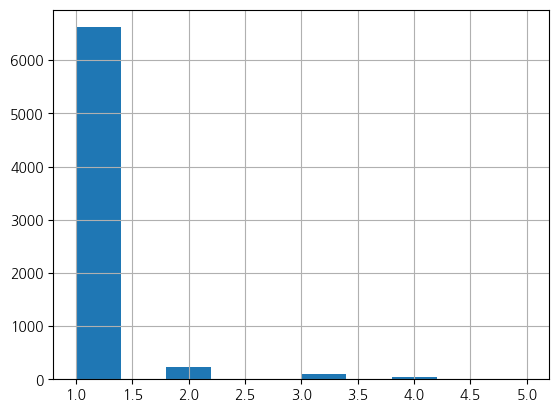

In [165]:
health_data['요 단백'].hist()
plt.show

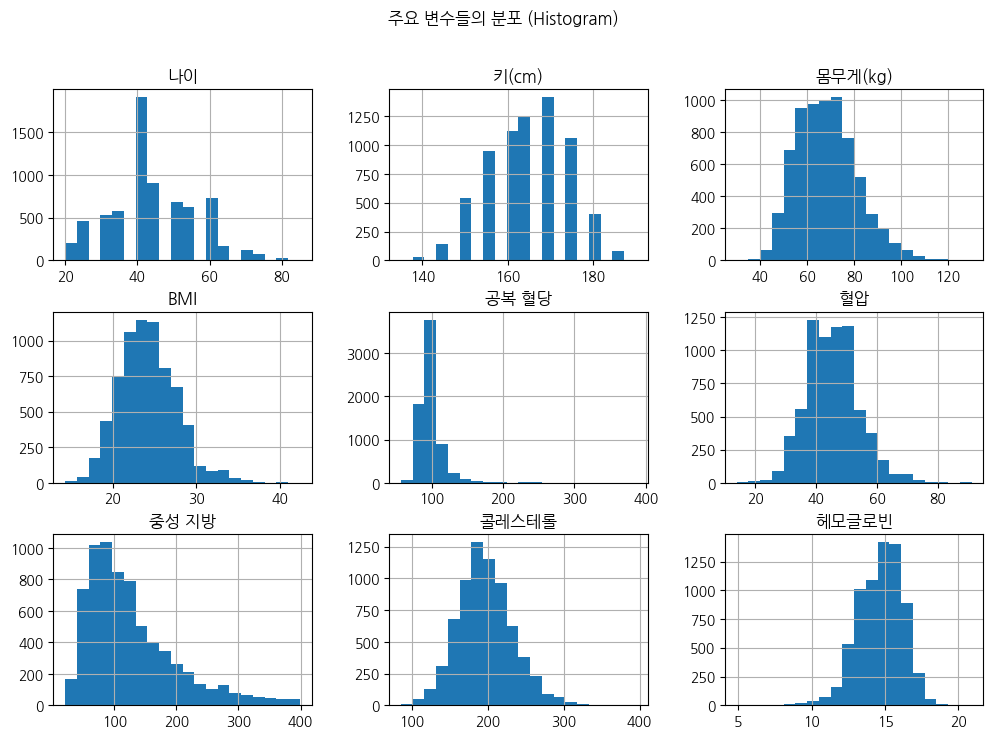

In [100]:
numeric_cols = [
    '나이', '키(cm)', '몸무게(kg)', 'BMI',
    '공복 혈당', '혈압', '중성 지방',
    '콜레스테롤', '헤모글로빈'
]

health_data[numeric_cols].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle("주요 변수들의 분포 (Histogram)")
plt.show()

Text(0, 0.5, '인원 수')

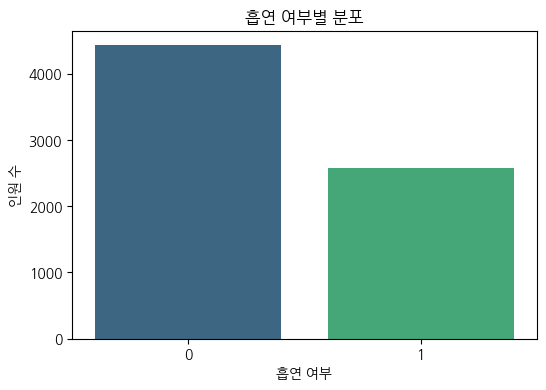

In [102]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.

plt.figure(figsize=(6, 4))
sns.countplot(data = health_data , x= 'label',
              hue = 'label',
              legend= False,
              palette= 'viridis'
              )
plt.title('흡연 여부별 분포')
plt.xlabel('흡연 여부')
plt.ylabel('인원 수')


In [103]:
pd.crosstab(
    health_data['label'],
    health_data['충치'],
    normalize=True
)


충치,0,1
label,,
0,0.508714,0.124000
1,0.263857,0.103429


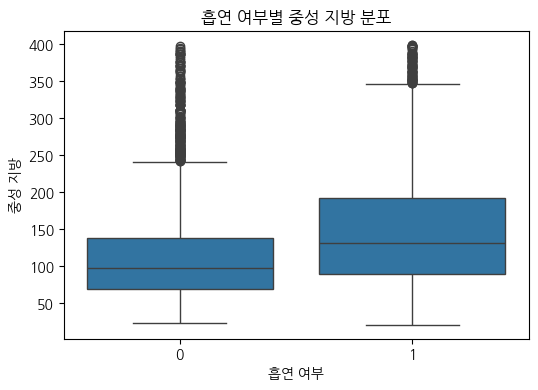

In [104]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=health_data,
    x='label',
    y='중성 지방'
)

plt.title("흡연 여부별 중성 지방 분포")
plt.xlabel("흡연 여부")
plt.ylabel("중성 지방")

plt.show()

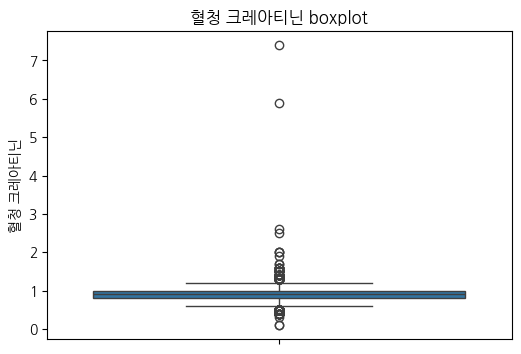

In [114]:
plt.figure(figsize=(6, 4))
sns.boxplot(y= health_data['혈청 크레아티닌'])
plt.title("혈청 크레아티닌 boxplot")
plt.show()

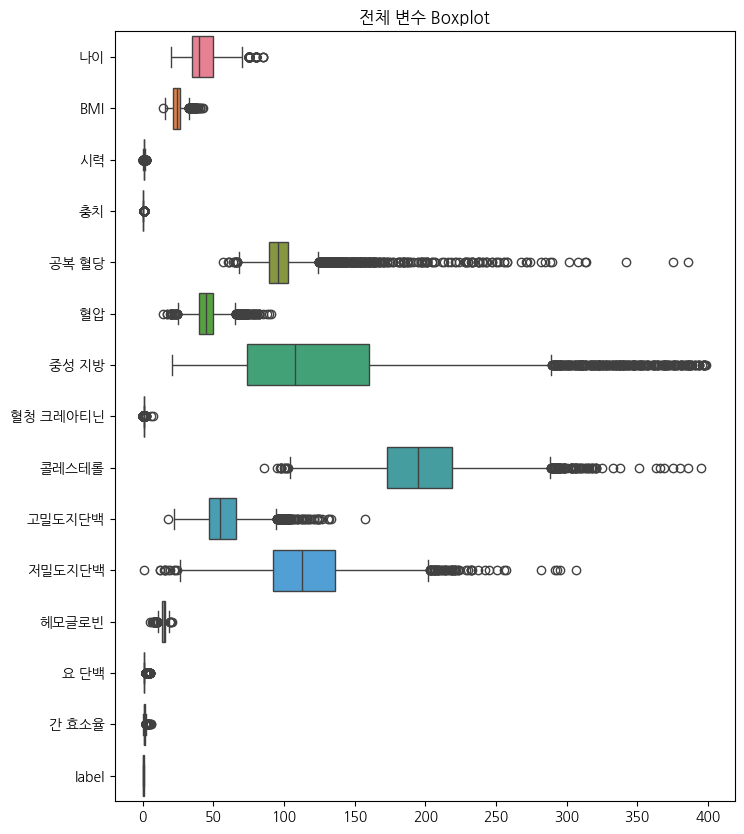

In [107]:
plt.figure(figsize=(8, 10))

sns.boxplot(
    data=model_data,
    orient='h'
)

plt.title("전체 변수 Boxplot")

plt.show()

---
## 4. 가설 수립하기 (최소 3개)
흡연 여부(label)에 따라 각 건강 지표에 통계적으로 유의미한 차이가 있는지 검증하기 위한 가설을 수립합니다.

각 건강 지표(예: BMI, 혈압, 혈당 등)에 대해 최소 3개 이상의 가설을 작성해 보세요.

**(예시)**
- H₀ (귀무가설): BMI- 흡연자와 비흡연자의 평균 BMI는 같다.
- H₁ (대립가설): BMI- 흡연자와 비흡연자의 평균 BMI는 다르다.

##### **[TODO] 3가지 분석 가설 설정**
- 아래 코드 셀에 흡연자와 비흡연자 간의 건강 지표 차이를 검증하기 위한 3가지 가설을 설정하세요.

In [ ]:
# 가설 1. Hb
# H₀ (귀무가설): 흡연자와 비흡연자의 평균 헤모글로빈 수치는 같다.
# H₁ (대립가설): 흡연자와 비흡연자의 평균 헤모글로빈 수치는 다르다.
# 가설 2.Triglyceride
# H₀ (귀무가설): 흡연자와 비흡연자의 평균 중성 지방 수치는 같다.
# H₁ (대립가설): 흡연자와 비흡연자의 평균 중성 지방 수치는 다르다.
# 가설 3.Serum Creatinine
# H₀ (귀무가설): 흡연자와 비흡연자의 평균 혈청 크레아티닌 수치는 같다.
# H₁ (대립가설): 흡연자와 비흡연자의 평균 혈청 크레아티닌 수치는 다르다.

---
## 5. 단변량 분석
단변량 분석은 각 변수(컬럼)의 특성을 개별적으로 탐색하는 과정입니다. 이를 통해 데이터의 전반적인 이해도를 높이고, 이상치나 결측값 등의 문제점을 파악할 수 있습니다.

#### 단변량 분석 목적:
-   **데이터 품질 확인**: 결측값, 이상치 등의 존재 여부를 파악합니다.
-   **변수 유형 이해**: 각 변수가 숫자형인지 범주형인지 구분하고, 데이터의 특성을 파악합니다.
-   **기초 통계량 확인**: 평균, 중앙값, 표준편차 등 핵심 통계치를 통해 데이터의 중심 경향과 퍼짐 정도를 파악합니다.
-   **분포 시각화**: 히스토그램, 박스 플롯 등을 통해 변수의 분포 형태를 시각적으로 확인합니다.
-   **전처리 필요성 판단**: NaN 값 처리, 가변수(Dummy Variable) 생성 등 추가 전처리 필요성을 결정합니다.
-   **비즈니스 인사이트 도출**: 각 변수가 어떤 의미를 가지며, 어떤 비즈니스적 함의를 갖는지 정리합니다.
-   **추가 분석 아이디어 발굴**: 단변량 분석 결과로부터 더 깊이 탐색할 만한 주제나 관계를 도출합니다.

##### **[TODO] 단변량 분석 수행**

다음 코드 셀에서 `health_data` DataFrame의 각 변수에 대해 단변량 분석을 수행해 보세요.

In [117]:
health_data['label'] = health_data['label'].astype('category')
health_data['충치'] = health_data['충치'].astype('category')

In [133]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
numeric_cols = health_data.select_dtypes(include='number').columns
for col in numeric_cols:
    print(f"\n==============={col}=================")
    print(f"결측치 수: {health_data[col].isnull().sum()}")
    print(health_data[col].describe())
    plt.figure(figsize=(12, 5))

    #hist
    plt.subplot(1, 2, 1)
    sns.histplot(health_data[col])
    plt.title(f"{col} histogram")

    #boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(data=health_data[col])
    plt.title(f"{col} boxplot")
    plt.show()


===============나이=================
결측치 수: 0
count    7000.000000
mean       43.973571
std        12.063793
min        20.000000
25%        35.000000
50%        40.000000
75%        50.000000
max        85.000000
Name: 나이, dtype: float64

===============키(cm)=================
결측치 수: 0
count    7000.000000
mean      164.781429
std         9.170213
min       135.000000
25%       160.000000
50%       165.000000
75%       170.000000
max       190.000000
Name: 키(cm), dtype: float64

===============몸무게(kg)=================
결측치 수: 0
count    7000.000000
mean       65.932857
std        12.978702
min        30.000000
25%        55.000000
50%        65.000000
75%        75.000000
max       130.000000
Name: 몸무게(kg), dtype: float64

===============BMI=================
결측치 수: 0
count    7000.000000
mean       24.144423
std         3.501945
min        14.270000
25%        21.600000
50%        23.880000
75%        26.120000
max        42.450000
Name: BMI, dtype: float64

===============시력============

In [132]:
categorical_cols = health_data.select_dtypes(include='category').columns

for col in categorical_cols:

    print(f"\n===== {col} =====")

    print(health_data[col].value_counts())

    plt.figure(figsize=(6, 4))

    sns.countplot(
        data=health_data,
        x=col
    )

    plt.title(f"{col} Countplot")
    plt.xticks(rotation=45)
    plt.show()


===== 충치 =====
충치
0    5408
1    1592
Name: count, dtype: int64

===== label =====
label
0    4429
1    2571
Name: count, dtype: int64

===== BMI 구간 =====
BMI 구간
정상        2734
1단계 비만    2093
비만전단계     1580
2단계 비만     322
저체중        230
3단계 비만      41
Name: count, dtype: int64

===== 나이대 =====
나이대
40대       2806
50대       1305
30대       1112
60대        894
20대        657
70대        194
70대 초과      32
Name: count, dtype: int64


# 단변량 분석 결과 요약

## 1. 데이터 품질

* 전체 데이터는 **7000건**으로 구성되어 있으며, 모든 변수에서 **결측치가 존재하지 않는다**.
* 데이터 전처리 부담이 적고, 모델링에 바로 활용 가능한 상태이다.

---

## 2. 타겟 변수(label) 분포

* label은 약 **63% : 37% 비율**로 비교적 균형 잡힌 분포를 보인다.

---

## 3. BMI 분포

* 정상보다 **비만 전단계 이상 집단의 비율이 더 높게 나타났다**.
* 이는 해당 데이터가 상대적으로 체중 관련 건강 위험 요인을 많이 포함하고 있음을 의미한다.
* BMI는 건강 상태를 설명하는 중요한 변수로 활용 가능하다.

---

## 4. 나이 분포

* 데이터는 **40대를 중심으로 한 중년층이 가장 많은 비율**을 차지한다.
* 20~60대가 대부분을 구성하고 있으며, 고령층 비율은 상대적으로 낮다.
* 따라서 이 데이터는 중년층 건강 특성을 중심으로 분석하는 것이 적절하다.

---

## 5. 주요 건강 지표 해석

* **공복 혈당**과 **혈청 크레아티닌**에서 매우 높은 값이 일부 관찰되어 이상치 존재 가능성이 있다.
* 이러한 값들은 실제 건강 이상을 의미할 수도 있지만, 분석 전 분포 확인이 필요하다.
* 대부분의 변수는 현실적인 범위 내에서 분포하고 있어 데이터 신뢰도는 전반적으로 양호한 편이다.

---

## 6. 혈압 변수 해석

* 혈압 평균이 약 45 수준으로 나타나 일반적인 혈압(mmHg) 값과 차이가 있다.
* 따라서 해당 변수는 실제 혈압 수치가 아니라 점수화된 건강 지표 또는 평균 동맥압(MAP)일 가능성이 높다.
* 분석 시 절대적인 수치보다 **상대적인 수준 비교 지표**로 해석하는 것이 적절하다.

---

## 7. 종합 해석

* 데이터는 결측치가 없고 분포가 전반적으로 안정적이어서 분석 및 모델링에 적합한 상태이다.
* BMI, 공복 혈당, 콜레스테롤, 나이 등은 건강 상태와 밀접한 관련이 있으므로 주요 설명 변수로 활용 가능하다.
* 일부 변수에서 이상치가 존재할 가능성이 있으므로, 이후 단계에서 추가적인 분포 확인 및 이변량 분석이 필요하다.


In [129]:
health_data[['혈압', 'BMI', '공복 혈당', '콜레스테롤']].corr()

,혈압,BMI,공복 혈당,콜레스테롤
혈압,1.000000,0.163847,0.089595,-0.013494
BMI,0.163847,1.000000,0.150908,0.092870
공복 혈당,0.089595,0.150908,1.000000,0.002630
콜레스테롤,-0.013494,0.092870,0.002630,1.000000


---
## 6. 이변량 분석
이변량 분석은 두 변수 간의 관계를 탐색하는 과정입니다. 이를 통해 변수들이 서로 어떻게 영향을 주고받는지 파악하고, 주요 예측 변수를 선별할 수 있습니다.

#### 이변량 분석의 목적

-   **변수 간 관계 탐색**: 원인-결과 관계 또는 상호 연관성을 파악합니다.
-   **주요 영향 요인 도출**: 어떤 변수가 목표 변수(예: 흡연 여부)에 가장 큰 영향을 미 미치는지 확인합니다.
-   **예측 모델 Feature 선별**: 향후 예측 모델 구축 시 중요한 특성(Feature) 후보를 선별합니다.

#### 가설 검정 가이드라인

수립한 가설들을 검정하기 위해 변수 유형에 따라 다음 통계 검정 방법을 활용합니다.

  - 유의수준 : 일반적으로 5% (0.05)를 기준으로 합니다.
  - 숫자형 변수 vs 숫자형 변수 : 상관분석 (Correlation Analysis)
  - 범주형 변수 vs 범주형 변수 : 카이제곱 검정 (Chi-squared Test)
  - 범주형 변수 vs 숫자형 변수 : t-검정 (t-test), 분산 분석 (ANOVA)
  - 숫자형 변수 vs 범주형 변수 : 로지스틱 회귀모형을 통해, 회귀계수의 P-value로 검정을 수행합니다.

##### **[TODO] 이변량 분석 수행**

다음 코드 셀에서 수립한 가설들을 바탕으로 이변량 분석을 수행하고, 결과를 해석해 보세요.

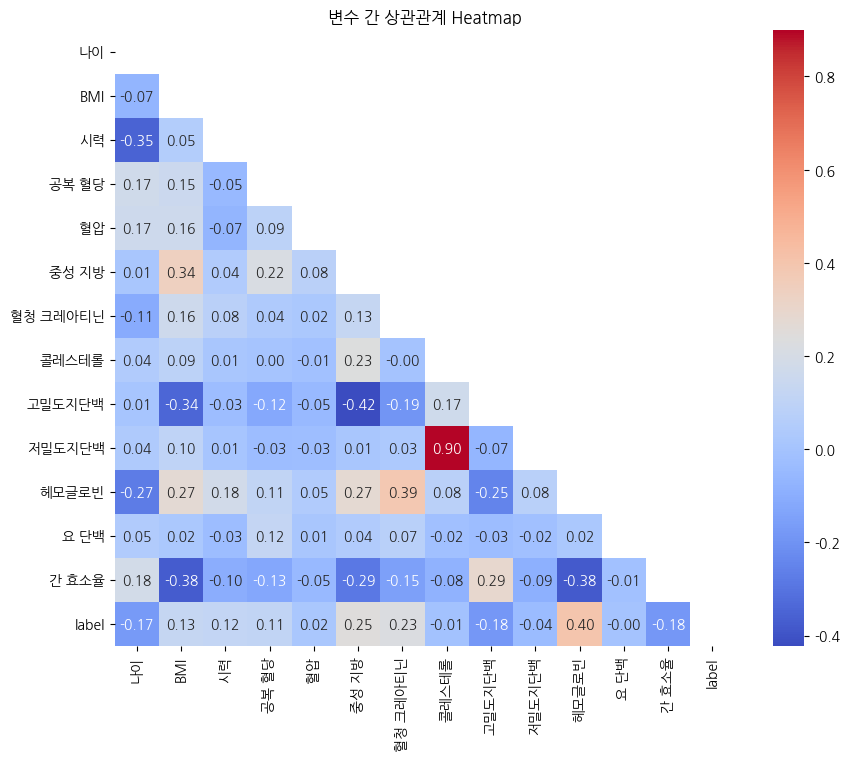

 1. 헤모글로빈               : 0.402
 2. 중성 지방               : 0.246
 3. 혈청 크레아티닌            : 0.226
 4. 간 효소율               : 0.184
 5. 고밀도지단백              : 0.181


In [161]:
import numpy as np

drop_cols = ['키(cm)', '몸무게(kg)']
model_data = health_data.drop(columns=drop_cols)
model_data['label']=model_data['label'].astype(int)

plt.figure(figsize=(10, 8))

corr = model_data.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("변수 간 상관관계 Heatmap")
plt.show()

label_corr = corr['label'].abs().sort_values(ascending=False)
for i, (var, corr) in enumerate(label_corr[1:6].items(),1):
    print(f"{i:2d}. {var:<20}: {corr:.3f}")

In [136]:
# 아래에 실습코드를 작성하고 결과를 확인합니다.
health_data.groupby('label')[[
    'BMI',
    '공복 혈당',
    '콜레스테롤',
    '혈압',
    '중성 지방'
]].mean()

,BMI,공복 혈당,콜레스테롤,혈압,중성 지방
label,,,,,
0,23.807094,97.539183,197.530368,45.417702,113.452965
1,24.725531,102.353162,196.839362,45.761571,150.396883


In [137]:
cols = [
    'BMI',
    '공복 혈당',
    '콜레스테롤',
    '중성 지방',
    '고밀도지단백',
    '저밀도지단백'
]

health_data[cols].corr()

,BMI,공복 혈당,콜레스테롤,중성 지방,고밀도지단백,저밀도지단백
BMI,1.000000,0.150908,0.092870,0.336813,-0.344352,0.102630
공복 혈당,0.150908,1.000000,0.002630,0.216293,-0.119630,-0.033474
콜레스테롤,0.092870,0.002630,1.000000,0.234578,0.167032,0.898713
중성 지방,0.336813,0.216293,0.234578,1.000000,-0.423337,0.014695
고밀도지단백,-0.344352,-0.119630,0.167032,-0.423337,1.000000,-0.066611
저밀도지단백,0.102630,-0.033474,0.898713,0.014695,-0.066611,1.000000


In [150]:
pd.crosstab(health_data['충치'], health_data['label'],normalize='index')

label,0,1
충치,,
0,0.658469,0.341531
1,0.545226,0.454774


In [168]:
model_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   ID        7000 non-null   str     
 1   나이        7000 non-null   int64   
 2   BMI       7000 non-null   float64 
 3   시력        7000 non-null   float64 
 4   충치        7000 non-null   category
 5   공복 혈당     7000 non-null   float64 
 6   혈압        7000 non-null   float64 
 7   중성 지방     7000 non-null   float64 
 8   혈청 크레아티닌  7000 non-null   float64 
 9   콜레스테롤     7000 non-null   int64   
 10  고밀도지단백    7000 non-null   int64   
 11  저밀도지단백    7000 non-null   float64 
 12  헤모글로빈     7000 non-null   float64 
 13  요 단백      7000 non-null   int64   
 14  간 효소율     7000 non-null   float64 
 15  label     7000 non-null   int64   
 16  BMI 구간    7000 non-null   category
 17  나이대       7000 non-null   category
dtypes: category(3), float64(9), int64(5), str(1)
memory usage: 841.5 KB


In [170]:

from scipy.stats import chi2_contingency

def cramers_v(table):
    chi2, p, dof, expected = chi2_contingency(table)
    n = table.sum().sum()
    r, k = table.shape
    v = np.sqrt(chi2 / (n * (min(k-1, r-1))))
    return chi2, p, v


model_data['요 단백'] = model_data['요 단백'].astype('category')
cat_cols = ['충치', '요 단백', 'BMI 구간', '나이대']

print("\n[카이제곱 검정 결과]")

for col in cat_cols:
    table = pd.crosstab(model_data[col], model_data['label'])

    chi2, p, v = cramers_v(table)

    print(f"{col:<15} p-value: {p:.5e} | Cramér's V: {v:.3f}")


[카이제곱 검정 결과]
충치              p-value: 2.23266e-16 | Cramér's V: 0.098
요 단백            p-value: 4.58916e-01 | Cramér's V: 0.023
BMI 구간          p-value: 1.42389e-23 | Cramér's V: 0.129
나이대             p-value: 1.27588e-48 | Cramér's V: 0.185


In [171]:
from scipy.stats import ttest_ind
import numpy as np

num_cols = model_data.select_dtypes(include=['float64', 'int64']).columns
num_cols = [c for c in num_cols if c != 'label']

# Cohen's d 함수
def cohens_d(x, y):
    x = x.dropna()
    y = y.dropna()

    nx, ny = len(x), len(y)
    sx, sy = np.var(x, ddof=1), np.var(y, ddof=1)

    pooled_std = np.sqrt(((nx-1)*sx + (ny-1)*sy) / (nx+ny-2))

    return (np.mean(x) - np.mean(y)) / pooled_std


print("\n[t-test + Effect Size 결과]")

for col in num_cols:
    group0 = model_data[model_data['label'] == 0][col]
    group1 = model_data[model_data['label'] == 1][col]

    t_stat, p = ttest_ind(group0, group1, nan_policy='omit')
    d = cohens_d(group0, group1)

    print(f"{col:<15} p-value: {p:.5e} | Cohen's d: {d:.3f}")


[t-test + Effect Size 결과]
나이              p-value: 4.34503e-49 | Cohen's d: 0.368
BMI             p-value: 2.42387e-26 | Cohen's d: -0.264
시력              p-value: 7.74682e-23 | Cohen's d: -0.245
공복 혈당           p-value: 1.64264e-20 | Cohen's d: -0.231
혈압              p-value: 1.12680e-01 | Cohen's d: -0.039
중성 지방           p-value: 9.45867e-97 | Cohen's d: -0.526
혈청 크레아티닌        p-value: 9.18048e-82 | Cohen's d: -0.481
콜레스테롤           p-value: 4.42746e-01 | Cohen's d: 0.019
고밀도지단백          p-value: 1.57307e-52 | Cohen's d: 0.381
저밀도지단백          p-value: 1.77209e-03 | Cohen's d: 0.078
헤모글로빈           p-value: 3.32125e-270 | Cohen's d: -0.911
간 효소율           p-value: 3.18337e-54 | Cohen's d: 0.388


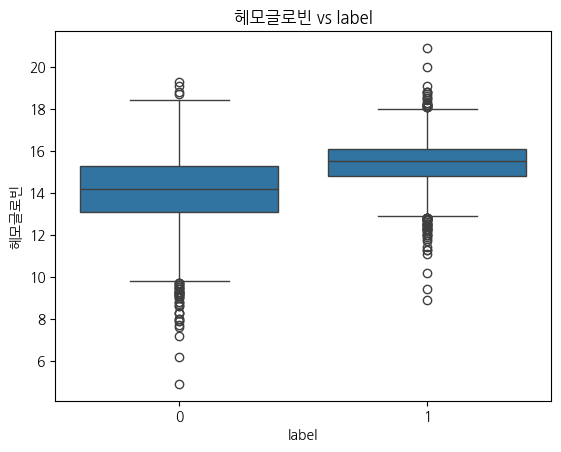

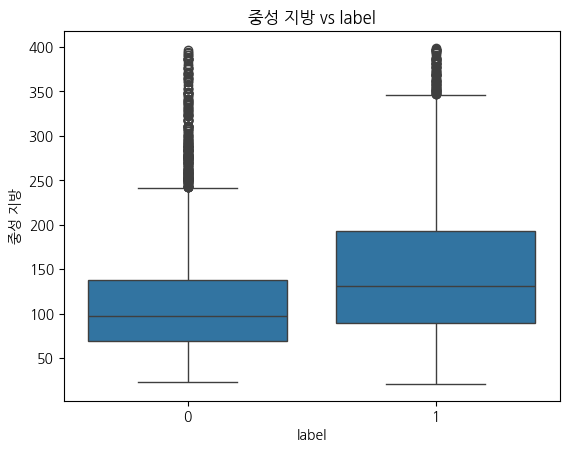

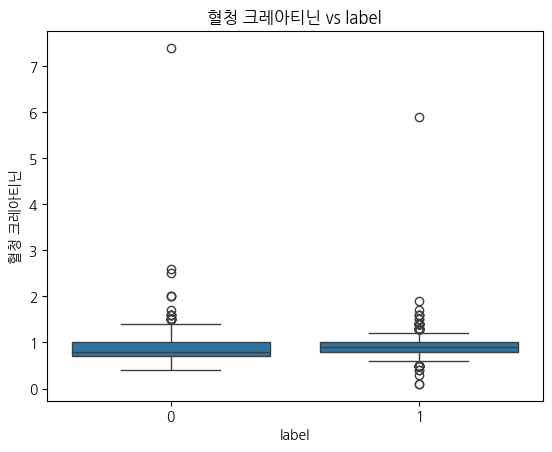

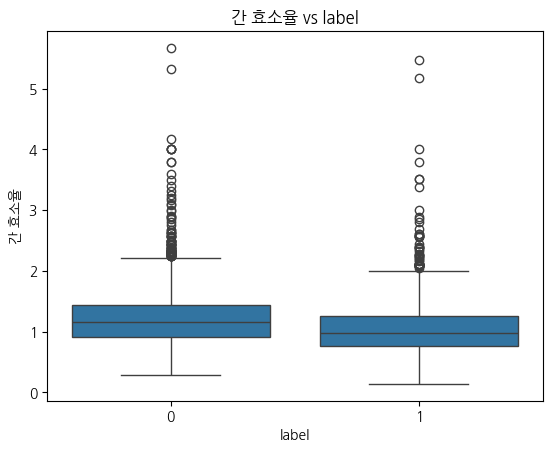

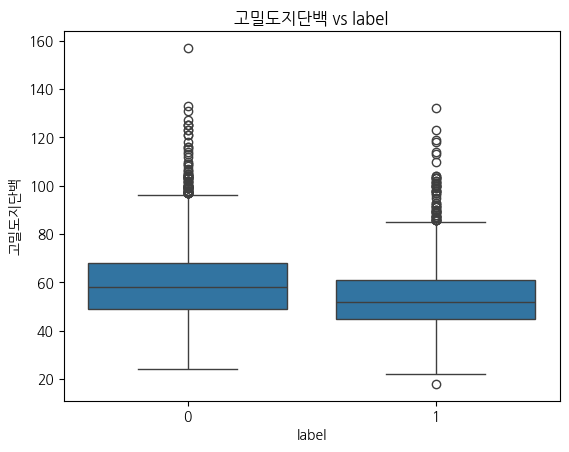

In [172]:
top_vars = label_corr[1:6].index

for var in top_vars:
    plt.figure()
    sns.boxplot(x='label', y=var, data=model_data)
    plt.title(f"{var} vs label")
    plt.show()

In [173]:
cat_cols_small = ['충치', '요 단백']

for col in cat_cols_small:
    display(pd.crosstab(model_data[col], model_data['label'], normalize='index'))

label,0,1
충치,,
0,0.658469,0.341531
1,0.545226,0.454774


label,0,1
요 단백,,
1,0.631611,0.368389
2,0.675325,0.324675
3,0.607477,0.392523
4,0.588235,0.411765
5,0.800000,0.200000


1. 범주형 변수와 흡연 여부

카이제곱 검정 결과, 충치, BMI 구간, 나이대는 흡연 여부와 통계적으로 유의한 연관성을 보였다 (p < 0.05).
그러나 Cramér’s V 기준으로 보면 전체적으로 약한 수준의 관계에 해당하였다.

나이대: V = 0.185 (가장 높은 수준의 연관성)
BMI 구간: V = 0.129
충치: V = 0.098
요 단백: 유의하지 않음 (p > 0.05)

즉, 일부 변수는 통계적으로 유의하나 설명력은 제한적인 수준이다.

2. 연속형 변수와 흡연 여부 (t-test 결과)

t-test 및 Cohen’s d 분석 결과, 일부 생리적 지표에서 흡연 여부에 따른 차이가 관찰되었다.

(1) 중간~강한 효과 크기

헤모글로빈: d = -0.911 (강한 차이)
중성지방: d = -0.526 (중간 수준)
혈청 크레아티닌: d = -0.481 (중간 수준)

흡연자는 비흡연자에 비해 위 지표에서 뚜렷한 차이를 보였다.

(2) 약한 효과 크기

BMI: d = -0.264
공복혈당: d = -0.231
시력: d = -0.245
간 효소율: d = 0.388 (약한~중간 경계)

해당 변수들은 통계적으로 유의하나 효과 크기는 작아 실질적인 차이는 제한적이다.

(3) 유의하지 않은 변수

혈압: p = 0.112, d ≈ 0
콜레스테롤: p > 0.05, d ≈ 0
LDL: 매우 작은 효과 크기

3. 방향성 해석

Cohen’s d의 부호를 기준으로 다음과 같은 경향이 확인되었다.

d < 0: 흡연자가 더 높은 값 (BMI, 중성지방, 혈당 등 일부 지표)
d > 0: 비흡연자가 더 높은 값 (HDL 등 건강 지표 일부)

특히 HDL(고밀도지단백)의 경우 비흡연자 그룹에서 더 높은 수치를 보여, 흡연이 건강 지표에 부정적인 방향으로 작용할 가능성을 시사한다.

4. 종합 해석

흡연 여부는 일부 건강 지표와 통계적으로 유의한 관계를 보였으나, 대부분의 변수에서 효과 크기는 약하거나 중간 수준에 머물렀다.

특히 헤모글로빈과 중성지방은 상대적으로 큰 효과 크기를 보여 흡연과의 관련성이 비교적 강하게 나타난 반면, BMI, 공복혈당, 시력 등은 약한 수준의 차이만 관찰되었다.

따라서 흡연은 특정 생리적 지표에는 의미 있는 영향을 미칠 수 있으나, 전반적인 건강 지표를 설명하는 강한 단일 요인으로 보기는 어렵다.

In [174]:
# 이변량 분석에서 파악한 내용을 정리해보세요.
#

## 7. 변수 간 상관관계 분석

다양한 건강 지표(숫자형 변수)들 간의 상호 관계를 심층적으로 분석합니다. BMI, 혈압, 혈당, 콜레스테롤 등 여러 지표가 어떻게 서로 연관되어 있는지 파악하여, 개인의 건강 상태를 보다 종합적으로 이해하고 향후 예측 모델 설계에 대한 중요한 통찰을 얻을 수 있습니다.

##### **[TODO] 상관계수 확인 및 HeatMap 시각화**
- `health_data`의 수치형 변수들 간의 상관계수를 계산하고, Heatmap으로 시각화하여 변수 간의 관계를 분석하세요.
  - **Heatmap**: 변수 간의 상관관계(Correlation)를 색상으로 쉽게 확인할 수 있는 시각화 방법입니다. 이를 통해 변수 간 관계를 한눈에 비교하고, 분석에 필요한 주요 변수를 파악할 수 있습니다.

#### 상관 계수 해석 기준:
-   **1에 가까울수록 (강한 양의 상관관계)**: 한 변수가 증가할 때 다른 변수도 함께 증가하는 경향이 매우 강합니다.
-   **-1에 가까울수록 (강한 음의 상관관계)**: 한 변수가 증가할 때 다른 변수는 감소하는 경향이 매우 강합니다.
-   **0에 가까울수록 (약한 상관관계)**: 두 변수 사이에 선형적인 관계가 거의 없거나 매우 약합니다.

In [ ]:
# 아래에 실습코드를 작성하고 상관계수를 확인 및 시각화 합니다.

In [ ]:
# 강한 관계를 보이는 변수에는 어떤 것이 있나요 ?
#

In [ ]:
# 약한 관계를 보이는 변수에는 어떤 것이 있나요 ?
#

## 8. 결론 및 인사이트 도출

지금까지의 데이터 분석 과정을 통해 흡연 여부와 관련된 건강 지표들 간의 관계를 탐색했습니다. 이제 이 모든 분석 결과를 종합하여 핵심적인 결론과 인사이트를 도출해 보세요.

##### **[TODO] 흡연 여부와 관련성 높은 요인 인사이트 제시**
- 종합 분석 결과와 가설 검정 결과를 바탕으로, 어떤 요인(변수)이 흡연 여부와 관련성이 높은지 인사이트를 제시하세요.

**(예시)**
- 흡연자는 비흡연자에 비해 평균 혈압과 중성지방 수치가 유의하게 높았습니다.(p<0.05)
- 반면, BMI는 유의한 차이가 없었습니다. (p>0.05)
- 따라서 흡연은 대사 관련 지표(혈압, 중성지방)에 더 큰 영향을 미치는 것으로 해석할 수 있습니다.

In [ ]:
# 어떤 요인이 흡연 여부와 관련성이 높을까요 ? 그 이유는?
#